In [1]:
!pip install ripser persim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.0/170.0 kB 1.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 776.5 kB/s eta 0:00:0000:0100:01
  Created wheel for hopcroftkarp: filename=hopcroftkarp-1.2.5-py2.py3-none-any.whl size=18188 sha256=db4c6e7d47d5fecac7e21bab2d1a3af34903a96306b66a0b2e31727cde6135c4
  Stored in directory: /Users/nhaile/Library/Caches/pip/wheels/2a/fd/fe/f4b8fd82894e1d9e04040ef41dc5ae6eb7a8e9b0ef5a9402fe
Successfully built hopcroftkarp


Running on cpu...

Training Depth 5...
  Epoch 1: Acc 95.1% | Movement 18.32
  Epoch 2: Acc 96.1% | Movement 22.39
  Epoch 3: Acc 96.9% | Movement 25.63
  Epoch 4: Acc 96.9% | Movement 28.29
  Epoch 5: Acc 97.5% | Movement 30.78
  Epoch 6: Acc 97.2% | Movement 32.99
  Epoch 7: Acc 96.9% | Movement 35.23

Training Depth 10...
  Epoch 1: Acc 91.8% | Movement 30.60
  Epoch 2: Acc 94.5% | Movement 38.51
  Epoch 3: Acc 95.0% | Movement 43.75
  Epoch 4: Acc 95.9% | Movement 48.15
  Epoch 5: Acc 95.8% | Movement 51.31
  Epoch 6: Acc 96.5% | Movement 54.77
  Epoch 7: Acc 96.3% | Movement 57.83

Training Depth 15...
  Epoch 1: Acc 91.9% | Movement 50.72
  Epoch 2: Acc 94.3% | Movement 63.89
  Epoch 3: Acc 94.9% | Movement 71.13
  Epoch 4: Acc 95.5% | Movement 77.26
  Epoch 5: Acc 94.8% | Movement 81.83
  Epoch 6: Acc 96.0% | Movement 86.52
  Epoch 7: Acc 96.2% | Movement 90.33

Training Depth 25...
  Epoch 1: Acc 11.3% | Movement 7.07
  Epoch 2: Acc 11.3% | Movement 8.36
  Epoch 3: Acc 11.3% | 

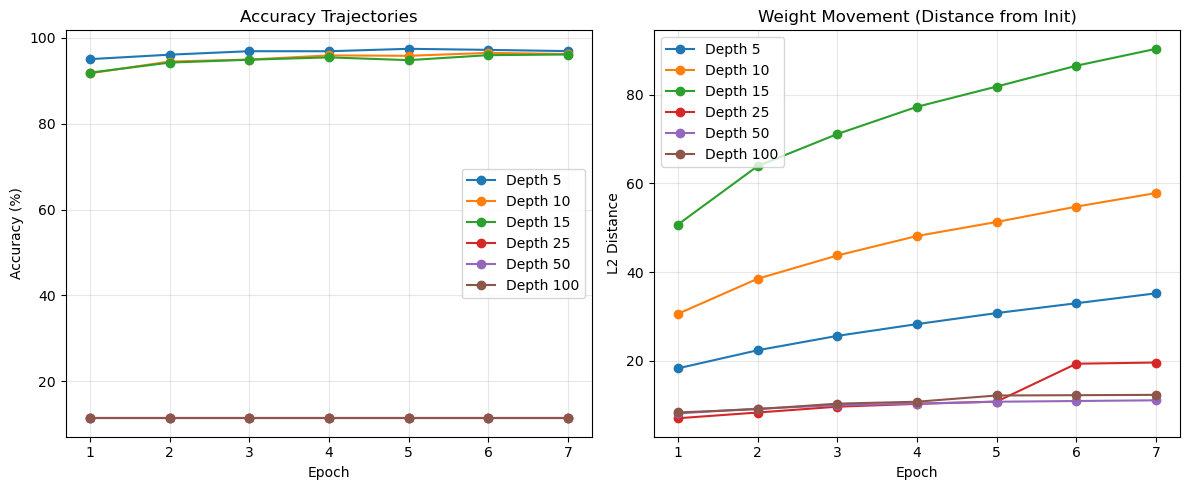


Running Persistent Homology on Embeddings...


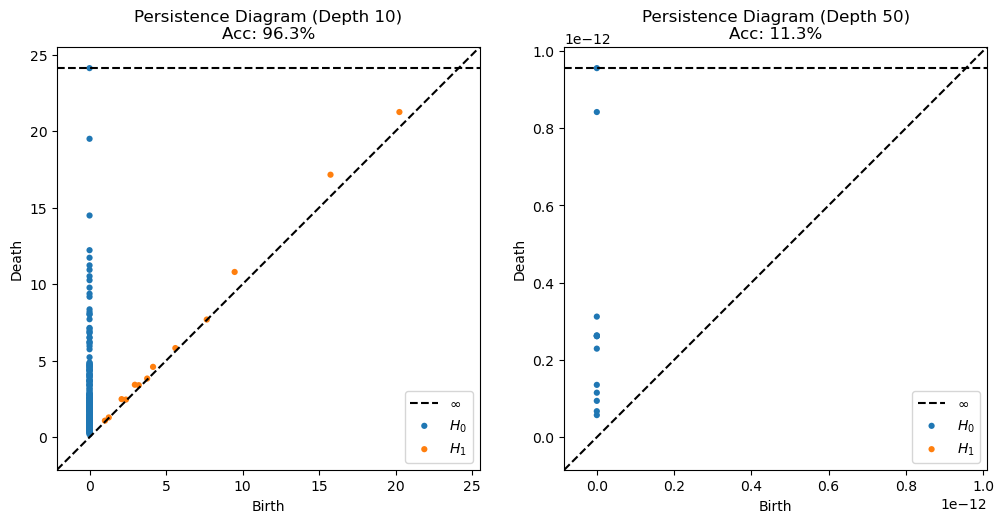

--------------------------------------------------
INTERPRETING THE PERSISTENCE DIAGRAMS
--------------------------------------------------
1. Orange Dots (H1/Loops): Points far from the diagonal indicate significant loops.
   - Expectation: Working models might show some loops (class separation).
   - Expectation: Collapsed models will have NO loops (flat geometry).

2. Blue Dots (H0/Components): Points far from diagonal indicate distinct clusters.
   - Expectation: Working models have many distinct components (one for each digit class).
   - Expectation: Collapsed models might collapse to a single component (signal death).


In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from ripser import ripser
from persim import plot_diagrams
from sklearn.decomposition import PCA

# ==========================================
# 1. CONFIGURATION & SETUP
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 64
LR = 0.001
EPOCHS = 7 # Keep it short; we just need to see if it trains or freezes
DEPTHS = [5, 10, 15, 25, 50, 100] # The list your mentor requested
WIDTH = 64 # We know 64 is a "good" width from last week

# Fixed seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print(f"Running on {DEVICE}...")

# Data Loaders
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_loader = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=transform), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(datasets.MNIST('./data', train=False, transform=transform), batch_size=200, shuffle=False) # Larger batch for PH

# ==========================================
# 2. MODEL DEFINITION (Standard MLP)
# ==========================================
class DynamicMLP(nn.Module):
    def __init__(self, depth, width):
        super().__init__()
        self.depth = depth
        self.flatten = nn.Flatten()
        self.input_layer = nn.Linear(28*28, width)
        self.hidden_layers = nn.ModuleList([nn.Linear(width, width) for _ in range(depth - 2)])
        self.output_layer = nn.Linear(width, 10)
        self.relu = nn.ReLU()
        
        # We need to store the initial state to calculate "Movement"
        self.initial_params = None

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.input_layer(x))
        for layer in self.hidden_layers:
            x = self.relu(layer(x))
        # We want the 'embedding' (activations before the final classifier) for PH
        embedding = x 
        out = self.output_layer(x)
        return out, embedding
    
    def save_initial_params(self):
        # Save a copy of initial weights to measure movement later
        self.initial_params = [p.clone().detach() for p in self.parameters()]

    def get_weight_movement(self):
        # Calculate L2 distance between current weights and initial weights
        current_params = [p.detach() for p in self.parameters()]
        dist = 0.0
        for p_init, p_curr in zip(self.initial_params, current_params):
            dist += torch.norm(p_curr - p_init).item()
        return dist

# ==========================================
# 3. THE EXPERIMENT LOOP
# ==========================================
results = {}

for depth in DEPTHS:
    print(f"\nTraining Depth {depth}...")
    model = DynamicMLP(depth, WIDTH).to(DEVICE)
    model.save_initial_params()
    
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()
    
    movements = []
    accuracies = []
    
    # Train
    for epoch in range(EPOCHS):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out, _ = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
        
        # Record Metric: Weight Movement
        movements.append(model.get_weight_movement())
        
        # Record Metric: Test Accuracy
        model.eval()
        correct = 0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out, _ = model(x)
                pred = out.argmax(dim=1)
                correct += (pred == y).sum().item()
        acc = 100 * correct / len(test_loader.dataset)
        accuracies.append(acc)
        print(f"  Epoch {epoch+1}: Acc {acc:.1f}% | Movement {movements[-1]:.2f}")

    # Store Final Embedding for PH
    # Get one batch of data
    x_test, y_test = next(iter(test_loader))
    x_test = x_test.to(DEVICE)
    with torch.no_grad():
        _, embeddings = model(x_test)
    
    results[depth] = {
        'accuracies': accuracies,
        'movements': movements,
        'embeddings': embeddings.cpu().numpy(),
        'labels': y_test.numpy()
    }

# ==========================================
# 4. VISUALIZATION: TRAINING MOVEMENTS
# ==========================================
plt.figure(figsize=(12, 5))

# Create an explicit range for the x-axis (1 to EPOCHS)
epoch_range = range(1, EPOCHS + 1)

# Plot 1: Accuracy vs Depth
plt.subplot(1, 2, 1)
for d in DEPTHS:
    # Pass epoch_range as the first argument to x-axis
    plt.plot(epoch_range, results[d]['accuracies'], label=f'Depth {d}', marker='o')

plt.title("Accuracy Trajectories")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.xticks(epoch_range) # <--- This forces integer ticks (1, 2, 3)
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Weight Movement vs Depth
plt.subplot(1, 2, 2)
for d in DEPTHS:
    # Pass epoch_range as the first argument to x-axis
    plt.plot(epoch_range, results[d]['movements'], label=f'Depth {d}', marker='o')

plt.title("Weight Movement (Distance from Init)")
plt.xlabel("Epoch")
plt.ylabel("L2 Distance")
plt.xticks(epoch_range) # <--- This forces integer ticks (1, 2, 3)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 5. PERSISTENT HOMOLOGY (THE MENTOR'S REQUEST)
# ==========================================
print("\nRunning Persistent Homology on Embeddings...")

# We will compare a "Working" Model (Depth 10) vs a "Collapsed" Model (Depth 50)
selected_depths = [10, 50] 

plt.figure(figsize=(12, 6))

for i, d in enumerate(selected_depths):
    if d not in results: continue
    
    emb = results[d]['embeddings']
    labels = results[d]['labels']
    
    # Optional: PCA reduction if embeddings are huge (helps PH speed)
    pca = PCA(n_components=10) # Reduce to 10 dims
    emb_reduced = pca.fit_transform(emb)
    
    # Compute Persistence Diagrams
    # H0 = Connected Components, H1 = Loops
    dgms = ripser(emb_reduced)['dgms']
    
    # Plot
    plt.subplot(1, 2, i+1)
    plot_diagrams(dgms, title=f"Persistence Diagram (Depth {d})\nAcc: {results[d]['accuracies'][-1]:.1f}%")

plt.show()

# ==========================================
# 6. INTERPRETATION HELPER
# ==========================================
print("-" * 50)
print("INTERPRETING THE PERSISTENCE DIAGRAMS")
print("-" * 50)
print("1. Orange Dots (H1/Loops): Points far from the diagonal indicate significant loops.")
print("   - Expectation: Working models might show some loops (class separation).")
print("   - Expectation: Collapsed models will have NO loops (flat geometry).")
print("\n2. Blue Dots (H0/Components): Points far from diagonal indicate distinct clusters.")
print("   - Expectation: Working models have many distinct components (one for each digit class).")
print("   - Expectation: Collapsed models might collapse to a single component (signal death).")

Training Reference Model (Depth 5)...
Ref Acc: 97.46%

--- Processing Depth 15 ---
Depth  | Loss       | alpha 
----------------------------
15     | 0.1048     | 0.00  
15     | 0.1088     | 0.04  
15     | 0.1234     | 0.08  
15     | 0.1543     | 0.12  
15     | 0.2139     | 0.17  
15     | 0.3179     | 0.21  
15     | 0.4668     | 0.25  
15     | 0.6376     | 0.29  
15     | 0.8102     | 0.33  
15     | 0.9666     | 0.38  
15     | 1.0838     | 0.42  
15     | 1.1429     | 0.46  
15     | 1.1365     | 0.50  
15     | 1.0658     | 0.54  
15     | 0.9396     | 0.58  
15     | 0.7742     | 0.62  
15     | 0.5936     | 0.67  
15     | 0.4240     | 0.71  
15     | 0.2848     | 0.75  
15     | 0.1856     | 0.79  
15     | 0.1263     | 0.83  
15     | 0.0969     | 0.88  
15     | 0.0855     | 0.92  
15     | 0.0847     | 0.96  
15     | 0.0914     | 1.00  

--- Processing Depth 25 ---
Depth  | Loss       | alpha 
----------------------------
25     | 0.1948     | 0.00  
25     | 0.2001   

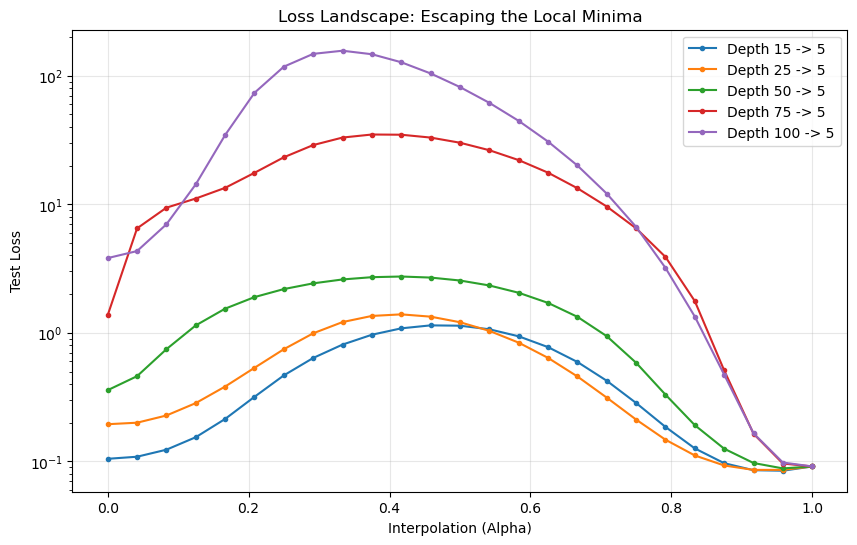

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import copy

# ==========================================
# 1. CONFIGURATION
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 64
LR = 0.001
EPOCHS_SMALL = 7  
EPOCHS_LARGE = 7  
WIDTH = 64        
DEPTH_SMALL = 5
DEPTHS_LARGE = [15, 25, 50, 75, 100] 
ALPHA_STEPS = 25  

torch.manual_seed(42)
np.random.seed(42)

# Data Loaders
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_loader = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=transform), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(datasets.MNIST('./data', train=False, transform=transform), batch_size=1000, shuffle=False)

# ==========================================
# 2. MODEL DEFINITION
# ==========================================
class ResBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.linear = nn.Linear(width, width)
        self.relu = nn.ReLU()
    def forward(self, x):
        return x + self.relu(self.linear(x)) 

class ResMLP(nn.Module):
    def __init__(self, depth, width):
        super().__init__()
        self.depth = depth
        self.flatten = nn.Flatten()
        self.input_layer = nn.Linear(28*28, width)
        self.blocks = nn.ModuleList([ResBlock(width) for _ in range(depth - 2)])
        self.output_layer = nn.Linear(width, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.input_layer(x))
        for block in self.blocks:
            x = block(x)
        out = self.output_layer(x)
        return out

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def train(model, epochs):
    model.train()
    opt = optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss()
    for e in range(epochs):
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            opt.step()

def evaluate(model):
    model.eval()
    crit = nn.CrossEntropyLoss()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            total_loss += crit(out, y).item()
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
    return total_loss / len(test_loader), 100 * correct / len(test_loader.dataset)

def graft_small_into_large(small_model, large_depth, width):
    large_model = ResMLP(large_depth, width).to(DEVICE)
    large_model.input_layer.load_state_dict(small_model.input_layer.state_dict())
    large_model.output_layer.load_state_dict(small_model.output_layer.state_dict())
    
    n_small_blocks = len(small_model.blocks)
    for i in range(n_small_blocks):
        large_model.blocks[i].load_state_dict(small_model.blocks[i].state_dict())
        
    for i in range(n_small_blocks, len(large_model.blocks)):
        nn.init.zeros_(large_model.blocks[i].linear.weight)
        nn.init.zeros_(large_model.blocks[i].linear.bias)
        
    return large_model

# ==========================================
# 4. EXECUTION
# ==========================================

# Step A: Train Reference Model
print(f"Training Reference Model (Depth {DEPTH_SMALL})...")
model_small = ResMLP(DEPTH_SMALL, WIDTH).to(DEVICE)
train(model_small, EPOCHS_SMALL)
loss_ref, acc_ref = evaluate(model_small)
print(f"Ref Acc: {acc_ref:.2f}%")

results = {}

# Step B: Loop through Large Depths
for depth in DEPTHS_LARGE:
    print(f"\n--- Processing Depth {depth} ---")
    
    # 1. Train Large
    model_large = ResMLP(depth, WIDTH).to(DEVICE)
    train(model_large, EPOCHS_LARGE)
    
    # 2. Create Target
    model_target = graft_small_into_large(model_small, depth, WIDTH)
    
    # 3. Interpolate & PRINT SIMPLE TABLE
    alphas = np.linspace(0, 1, ALPHA_STEPS)
    losses = []
    model_mix = ResMLP(depth, WIDTH).to(DEVICE)
    
    # Table Header
    print(f"{'Depth':<6} | {'Loss':<10} | {'alpha':<6}")
    print("-" * 28)

    for alpha in alphas:
        # Interpolate parameters
        for p_mix, p_bad, p_good in zip(model_mix.parameters(), model_large.parameters(), model_target.parameters()):
            p_mix.data = (1 - alpha) * p_bad.data + alpha * p_good.data
            
        l, a = evaluate(model_mix)
        losses.append(l)
        
        # PRINT ROW
        print(f"{depth:<6} | {l:<10.4f} | {alpha:<6.2f}")

    results[depth] = {'losses': losses, 'alphas': alphas}

# ==========================================
# 5. PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))
for depth in DEPTHS_LARGE:
    plt.plot(results[depth]['alphas'], results[depth]['losses'], label=f'Depth {depth} -> 5', marker='.')

plt.title("Loss Landscape: Escaping the Local Minima")
plt.xlabel("Interpolation (Alpha)")
plt.ylabel("Test Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

Training Reference Model (Depth 5)...
Ref Acc: 97.19%

--- Processing Depth 15 ---
Depth  | Loss       | alpha 
----------------------------
15     | 0.1491     | 0.00  
15     | 0.1687     | 0.04  
15     | 0.3357     | 0.08  
15     | 0.8085     | 0.12  
15     | 1.3745     | 0.17  
15     | 1.8156     | 0.21  
15     | 2.1013     | 0.25  
15     | 2.2630     | 0.29  
15     | 2.3290     | 0.33  
15     | 2.3450     | 0.38  
15     | 2.3473     | 0.42  
15     | 2.3435     | 0.46  
15     | 2.3358     | 0.50  
15     | 2.3274     | 0.54  
15     | 2.3206     | 0.58  
15     | 2.3158     | 0.62  
15     | 2.3114     | 0.67  
15     | 2.3028     | 0.71  
15     | 2.2733     | 0.75  
15     | 2.1678     | 0.79  
15     | 1.8841     | 0.83  
15     | 1.2966     | 0.88  
15     | 0.5179     | 0.92  
15     | 0.1308     | 0.96  
15     | 0.0983     | 1.00  

--- Processing Depth 25 ---
Depth  | Loss       | alpha 
----------------------------
25     | 2.3011     | 0.00  
25     | 2.3012   

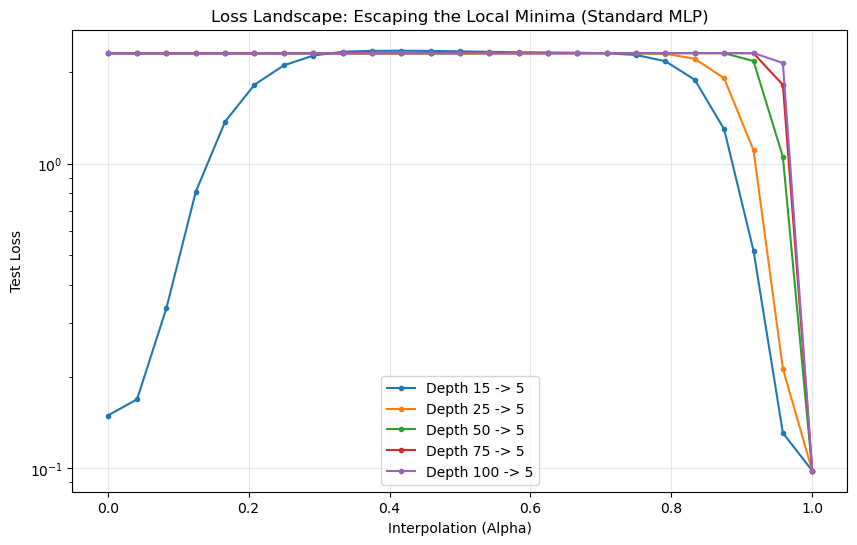

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import copy

# ==========================================
# 1. CONFIGURATION
# ==========================================
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 64
LR = 0.001
EPOCHS_SMALL = 7  
EPOCHS_LARGE = 7  
WIDTH = 64        
DEPTH_SMALL = 5
DEPTHS_LARGE = [15, 25, 50, 75, 100] 
ALPHA_STEPS = 25  

torch.manual_seed(42)
np.random.seed(42)

# Data Loaders
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_loader = DataLoader(datasets.MNIST('./data', train=True, download=True, transform=transform), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(datasets.MNIST('./data', train=False, transform=transform), batch_size=1000, shuffle=False)

# ==========================================
# 2. MODEL DEFINITION (Standard MLP)
# ==========================================
class MLPBlock(nn.Module):
    def __init__(self, width):
        super().__init__()
        self.linear = nn.Linear(width, width)
        self.relu = nn.ReLU()
    def forward(self, x):
        # CHANGED: Removed "x + " (No skip connection)
        return self.relu(self.linear(x)) 

class StandardMLP(nn.Module):
    def __init__(self, depth, width):
        super().__init__()
        self.depth = depth
        self.flatten = nn.Flatten()
        self.input_layer = nn.Linear(28*28, width)
        self.blocks = nn.ModuleList([MLPBlock(width) for _ in range(depth - 2)])
        self.output_layer = nn.Linear(width, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.input_layer(x))
        for block in self.blocks:
            x = block(x)
        out = self.output_layer(x)
        return out

# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================
def train(model, epochs):
    model.train()
    opt = optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss()
    for e in range(epochs):
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward()
            opt.step()

def evaluate(model):
    model.eval()
    crit = nn.CrossEntropyLoss()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            total_loss += crit(out, y).item()
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
    return total_loss / len(test_loader), 100 * correct / len(test_loader.dataset)

def graft_small_into_large(small_model, large_depth, width):
    large_model = StandardMLP(large_depth, width).to(DEVICE)
    large_model.input_layer.load_state_dict(small_model.input_layer.state_dict())
    large_model.output_layer.load_state_dict(small_model.output_layer.state_dict())
    
    n_small_blocks = len(small_model.blocks)
    
    # 1. Copy the active small blocks
    for i in range(n_small_blocks):
        large_model.blocks[i].load_state_dict(small_model.blocks[i].state_dict())
        
    # 2. Set EXTRA blocks to Identity
    # CHANGED: For MLP, we must use Identity Matrix (eye) instead of Zeros
    # Because ReLU(Identity * x) = x (since x is already non-negative from previous ReLU)
    for i in range(n_small_blocks, len(large_model.blocks)):
        nn.init.eye_(large_model.blocks[i].linear.weight)
        nn.init.zeros_(large_model.blocks[i].linear.bias)
        
    return large_model

# ==========================================
# 4. EXECUTION
# ==========================================

# Step A: Train Reference Model
print(f"Training Reference Model (Depth {DEPTH_SMALL})...")
model_small = StandardMLP(DEPTH_SMALL, WIDTH).to(DEVICE)
train(model_small, EPOCHS_SMALL)
loss_ref, acc_ref = evaluate(model_small)
print(f"Ref Acc: {acc_ref:.2f}%")

results = {}

# Step B: Loop through Large Depths
for depth in DEPTHS_LARGE:
    print(f"\n--- Processing Depth {depth} ---")
    
    # 1. Train Large
    model_large = StandardMLP(depth, WIDTH).to(DEVICE)
    train(model_large, EPOCHS_LARGE)
    
    # 2. Create Target
    model_target = graft_small_into_large(model_small, depth, WIDTH)
    
    # 3. Interpolate & PRINT SIMPLE TABLE
    alphas = np.linspace(0, 1, ALPHA_STEPS)
    losses = []
    model_mix = StandardMLP(depth, WIDTH).to(DEVICE)
    
    # Table Header
    print(f"{'Depth':<6} | {'Loss':<10} | {'alpha':<6}")
    print("-" * 28)

    for alpha in alphas:
        # Interpolate parameters
        for p_mix, p_bad, p_good in zip(model_mix.parameters(), model_large.parameters(), model_target.parameters()):
            p_mix.data = (1 - alpha) * p_bad.data + alpha * p_good.data
            
        l, a = evaluate(model_mix)
        losses.append(l)
        
        # PRINT ROW
        print(f"{depth:<6} | {l:<10.4f} | {alpha:<6.2f}")

    results[depth] = {'losses': losses, 'alphas': alphas}

# ==========================================
# 5. PLOTTING
# ==========================================
plt.figure(figsize=(10, 6))
for depth in DEPTHS_LARGE:
    plt.plot(results[depth]['alphas'], results[depth]['losses'], label=f'Depth {depth} -> 5', marker='.')

plt.title("Loss Landscape: Escaping the Local Minima (Standard MLP)")
plt.xlabel("Interpolation (Alpha)")
plt.ylabel("Test Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()